## Cell Tracking path calculation

In this notebook the position and the tracks of the cells is recovered.

First we need to set a few general parameters:

YOUR_DATA_PATH - This variable specifies the location of your raw image data.

OUTPUT_PATH - This defines the directory where the processed output data, including the cell tracks will be saved.

IMAGE_CHANNEL - This parameter indicates the color channel of the images that should be used for the analysis. 0 - red; 1 - green; 2 - blue, for gray images this does not really matter as gray is converted into RGB when reading images.

In [1]:
import os
WORK_DIR = os.getcwd()
PATH_OF_SRC_MODUL = WORK_DIR.replace("notebooks", "src")
YOUR_DATA_PATH = r"/sc-projects/sc-proj-cc06-agsack/noja11/CellTrack/Training/Dataset/Fluo-N2DH-GOWT1/01"
OUTPUT_PATH = r"/sc-projects/sc-proj-cc06-agsack/noja11/CellTrack/Training/Dataset/Fluo-N2DH-GOWT1/01_RES"
IMAGE_CHANNEL = 1

Before loading the data or running any analysis, we first need to import all necessary Python packages and modules that the notebook depends on.

In [2]:
import sys
sys.path.append(PATH_OF_SRC_MODUL)
import algo_funcs as algo
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
import numpy as np
from matplotlib import colors
import scipy
import json
from matplotlib.patches import Rectangle
import cv2
import random

## Reading images

In this section, we specify how the cell tracking algorithm should locate and read your image files. We assume that your raw image sequences are stored within the directory defined by `YOUR_DATA_PATH`.

Let's consider a common naming convention for time-series image stacks. If your image files are named in a pattern like `XXXX_01.tif`, `XXXX_02.tif`, ..., `XXXX_NN.tif`, where `XXXX` is a some prefix and `01`, `02`, ..., `NN` represent sequential time points, then `IMAGE_PATHS_PATTERN` needs to be set in the following way: 

IMAGE_PATHS_PATTERN = rf'{YOUR_DATA_PATH}/XXXX_*.tif'

**IMPORTANT**: Numbers need to be given with leading zeros. This means if you have 200 images the images should be numbered in the following way XXX_000.tif, XXX_001.tif, XXX_002.tif...

Furthermore the IMAGE_CHANNEL is set.

In [3]:
IMAGE_PATHS_PATTERN = rf'{YOUR_DATA_PATH}/t*.tif'
algo.IMAGE_CHANNEL = IMAGE_CHANNEL
DATASET_NAME = os.path.splitext(os.path.basename(IMAGE_PATHS_PATTERN))[0]
os.makedirs(OUTPUT_PATH,exist_ok=True)

With the file pattern defined, we can now load the images into memory and rescale them to [0,255].

In [4]:
images = algo.read_images(directory = IMAGE_PATHS_PATTERN, is_gray_scale = True)
images = algo.batch_rescale_rgb_to_255(images)
images_unchanged = images.copy()

## Preprocessing

### Sequential Image Registration

This code corrects overall drift in the image sequence by applying a series of rigid and affine registration steps. Because each image must be aligned in order, the process is slow and runs sequentially. It’s recommended to run this step only once, then save the registered results using `algo.save_images`. After that, you can load the already-registered images directly by updating the path in the cell above.

In [ ]:
transformed_images = images

for i in range(len(images)-1):
    transformed_images[i+1] = algo.image_registration(fixed_img = transformed_images[i], moving_img = images[i+1], registration_channel = 2, n_processes=12)

images = transformed_images

algo.save_images(images = transformed_images, directory = rf"{OUTPUT_PATH}/reg", pattern = f"{DATASET_NAME}_")

### Mean Subtraction

Since we are primarily interested in detecting **moving cells**, we can compute the **mean image** across the entire stack and subtract it from each frame using `algo.subtract_mean_channel`.  
This enhances the contrast of moving structures while suppressing static background features and noise.  
We can also plot the mean image for reference.

---

The function `algo.sliding_mean_subtraction()` applies a *local* mean subtraction using a sliding window.  
For example, with `window_size = 8`, the function computes the mean of the **four frames before** and **four frames after** the current one and subtracts this local mean.

The function returns:
- the **mean-subtracted image**
- the **sliding-window mean** itself

---

> **Note:** These steps are optional and can also be performed **after denoising**.

In [ ]:
images, mean_img = algo.subtract_mean_channel(images = images)
images = [np.where(img > 100, 0, img) for img in images]
images = algo.batch_rescale_rgb_to_255(images)

#substracted_images, sliding_mean_img = algo.sliding_mean_subtraction(images = images, window_size = 8)

fig, axes = plt.subplots(1, 2)

im1 = axes[0].imshow(np.array(images[0],dtype=np.uint8))
axes[0].set_title('Substracted Image')
axes[0].axis('off')

im2 = axes[1].imshow(np.array(mean_img,dtype=np.uint8))
axes[1].set_title('Mean image')
axes[1].axis('off')
plt.tight_layout()  

### Filtering

A range of denoising and postprocessing methods can be applied to improve image quality and emphasize relevant structures.  

- `algo.bm3d_denoise_all` — applies BM3D denoising to all images.
- `algo.log_transform_all` — applies a log transformation to highlight low-intensity features.
- `algo.wavelet_denoise_all` — performs wavelet-based denoising across all images.
- `algo.monogenic_filter_all_images` — applies monogenic filtering, useful for enhancing phase-based and textural details.
- `algo.unsharp_mask_all` — applies unsharp masking;  
  `radius` should reflect the approximate pixel radius of a cell, and `amount` controls the level of contrast sharpening.

These steps can be combined freely, and their order can be adjusted depending on the specific processing workflow.

In [5]:
#images = algo.bm3d_denoise_all(images = images)
#images = algo.log_transform_all(images=images)
images = algo.wavelet_denoise_all(images = images)
#images = algo.median_denoise_all(images = images, size = 3)
#images = algo.monogenic_filter_all_images(images = images)
#images = algo.unsharp_mask_all(images = images, radius = 50, amount =5)

Let's display the processed image alongside the original to assess whether the cells are now more clearly visible. `frame` specifies which image to display in the sequence

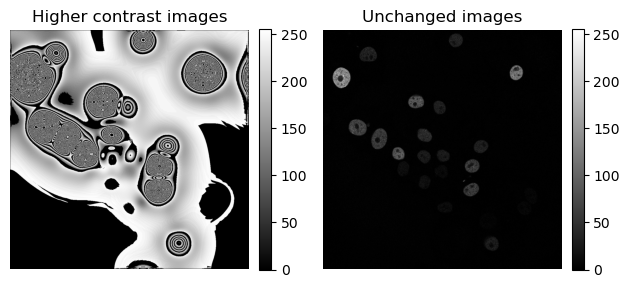

In [7]:
fig, axes = plt.subplots(1, 2)
frame = 0

im1 = axes[0].imshow(np.array(images[frame][..., IMAGE_CHANNEL], dtype=np.uint8),
    cmap='gray')
axes[0].set_title('Higher contrast images')
axes[0].axis('off')
fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)

im2 = axes[1].imshow(np.array(images_unchanged[frame][..., IMAGE_CHANNEL], dtype=np.uint8),
    cmap='gray')
axes[1].set_title('Unchanged images')
axes[1].axis('off')
fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(rf"/{OUTPUT_PATH}/contrast_enh.png", bbox_inches='tight')

## Cell detection

You can determine cell centers using either **local-maxima detection**, **centroid estimation** or **`algo.locate_all_cells_monogenic_filter`**.  
The best choice depends on the properties of your data:

- **Larger cells:** centroid detection usually yields smoother, more stable trajectories.  
- **Very small cells (~5 px) that cannot be cleanly segmented:** local-maxima detection is often more reliable.
- **`algo.locate_all_cells_monogenic_filter`**, applies a monogenic filter to enhance local phase information. This can improve detection performance in datasets where cell boundaries or texture features are more distinct in the phase domain.

---

- **`min_size`**  
  The minimum allowed cell mask size. Masks smaller than this are discarded.

- **`manual_threshold`**  
  Optional. If provided, the threshold is applied directly. If not, Otsu thresholding is used.

- **`iterations`**  
  Number of binary closing iterations applied to the mask.

- **`min_distance`**  
  Minimum distance allowed between detected centers. Only one centroid is kept within any `min_distance` radius.

- **`expected_mask_size`**  
  Approximate size (in pixels) of a single cell.  
  If a detected mask exceeds this size, the algorithm attempts to split it.  
  *Example:* a mask of 60 px with `expected_mask_size = 40` will be evaluated for two cells.

- **`cw_monogenic`**  
  Scales used for the monogenic filters.

- **`T`**  
  Threshold applied to the monogenic filter output.


In [12]:
edges_list, mask_list = algo.locate_all_cells_centroids(images = images, min_size = 120, manual_threshold = 100, iterations =1, min_distance = 50)
#edges_list, mask_list = algo.locate_all_cells_monogenic_filter(images, cw_monogenic=np.array([50.0, 60.0, 70.0]), T=0.6, min_distance=30)
#edges_list, mask_list = algo.locate_all_cells_local_maxima(images = images, min_size=20, expected_mask_size=800, min_distance = 10)

Now let’s examine how many cells were detected in each image.

If the number of cells entering and leaving the field of view is roughly balanced, we would expect this curve to remain relatively flat over time. In contrast, a noticeable upward trend in the curve would indicate that the cell population is increasing.

Text(0, 0.5, 'Number of detected Cells')

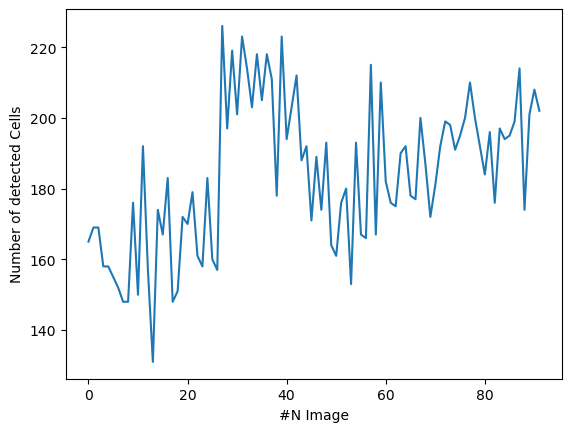

In [13]:
num_edges = [len(edges) for edges in edges_list]

plt.plot(num_edges)
plt.xlabel("#N Image")
plt.ylabel("Number of detected Cells")

Now let's inspect the actual image along with the detected cell locations.  

You can adjust `zoom_x` and `zoom_y` to focus on different regions of the image by zooming in at specific coordinates. `frame` specifies which frame or image in the sequence to display.

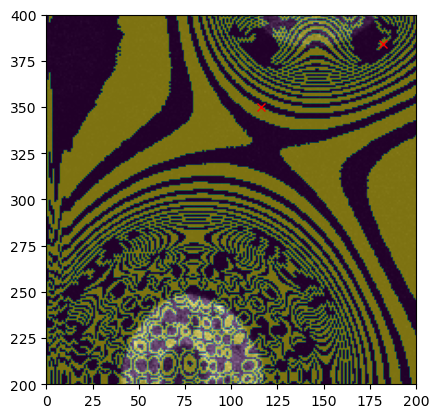

In [14]:
zoom_x = (0,200)
zoom_y = (200,400)
frame = 0

plt.imshow(np.array(images_unchanged[frame][..., IMAGE_CHANNEL],dtype=np.uint8),
    cmap='gray')
plt.imshow(mask_list[frame],alpha=0.5)
edges = edges_list[frame]
for edge in edges:
    plt.plot(edge[0], edge[1], 'rx') 
plt.xlim(zoom_x)
plt.ylim(zoom_y)
plt.savefig(rf"/{OUTPUT_PATH}/detected_cells.png", bbox_inches='tight')

If the detection shows too many or too few cells, you can fine-tune the parameters above to adjust the results.  
Once you're satisfied with the detections, you can also generate a video to visualize the full sequence!

In [15]:
frame_width = images_unchanged[0].shape[1]
frame_height = images_unchanged[0].shape[0]
fps = 10  # Frames per second
output_video = cv2.VideoWriter(f"{OUTPUT_PATH}/detected_edges.mp4", cv2.VideoWriter_fourcc(*'mp4v'), fps, (frame_width, frame_height))

# Iterate through the unsharp_mask frames and edges
for frame_idx in range(0, len(images_unchanged)):
    img = images_unchanged[frame_idx]  
    
    img = np.array(img,dtype=np.uint8)
    
    img = cv2.resize(img, (frame_width, frame_height))
    
    img_bgr = img

    edges = edges_list[frame_idx]
    for edge in edges:
        x, y = int(edge[0]), int(edge[1]) 
        cv2.circle(img_bgr, (x, y), 5, (0, 0, 255), -1)

    cv2.putText(img_bgr, f"Frame {frame_idx}", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    output_video.write(img_bgr)

output_video.release()

## Cell tracking

Now we can begin recovering the actual cell trajectories. Detected cells across consecutive images are assembled into continuous paths.

- **`max_distance`**  
  Specifies the maximum distance a cell is allowed to move from one frame to the next in order to be recognized as the same cell. Adjusting this value helps ensure that fast-moving cells are correctly tracked while preventing incorrect linkages between unrelated detections.

In [16]:
dict_list, average_flow = algo.track_points_optical_flow(images = np.array(images_unchanged,dtype = np.uint8), all_points = edges_list, mask_list = mask_list, max_distance = 60)

Now let's export the reconstructed paths along with the annotated images!

In [ ]:
os.makedirs(rf"/{OUTPUT_PATH}/".replace("*",""),exist_ok=True)
np.save(rf"/{OUTPUT_PATH}/calc_paths.npy".replace("*",""),  dict_list) 
algo.save_images(images = images, directory = rf"{OUTPUT_PATH}".replace("*",""), pattern = f"{DATASET_NAME}".replace("*",""))

Finally, we can visualize the average flow computed from the optical flow results.  

This provides indication into regions with high movement as well as areas where little to no motion occurs.

In [ ]:
plt.imshow(average_flow)